In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
users_info = pd.read_csv('../data/users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### 1. EDA
**Проведение первичного анализ данных:**

- размер и типы данных таблицы

- обработка пропусков

- удаление выбросов по возрасту (IQR)

- визуализация распределения возрастов

In [3]:
#Размер таблицы
users_info.shape

(1000, 4)

In [4]:
#Типы колонок
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [5]:
#Пропущенные значения
users_info.isna().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [6]:
#Пропущенные значения в процентах от всех строк в столбце
users_info.isna().sum() / users_info.count() * 100

id_user    0.000000
city       0.000000
age        9.649123
gender     9.769484
dtype: float64

In [7]:
#Удаление строк с пустыми значениями
users_info_cleaned = users_info.dropna()

In [8]:
#Размер очищенной таблицы
users_info_cleaned.shape

(865, 4)

In [9]:
#Процент удаленных данных:
print(f'Удалено {round((users_info.shape[0] - users_info_cleaned.shape[0]) / users_info.shape[0]*100, 2)} % данных')

Удалено 13.5 % данных


In [10]:
# Расчёт квартилей и интерквартильного размаха
q1 = np.percentile(users_info_cleaned['age'], 25)
q2 = np.percentile(users_info_cleaned['age'], 50)
q3 = np.percentile(users_info_cleaned['age'], 75)
iqr = q3 - q1
print(f'q1: {q1}, q2: {q2}, q3: {q3}, iqr: {iqr}, границы: от {q1 - 1.5 * iqr} до {q3 + 1.5 * iqr}')

q1: 28.0, q2: 37.0, q3: 51.0, iqr: 23.0, границы: от -6.5 до 85.5


In [11]:
# Узнаем крайние значения в колонке 'age'
print(f"Максимальный возраст: {users_info_cleaned['age'].max()}\nМинимальный возраст: {users_info_cleaned['age'].min()}")

Максимальный возраст: 65.0
Минимальный возраст: 18.0


In [12]:
# Нет возрастов, которые бы выходили за рамки пороговых значений.
# Но если бы такие были, их очистка производилась следующим образом:

users_info_cleaned = \
    users_info_cleaned[(users_info_cleaned['age'] >= (q1 - 1.5 * iqr)) & (users_info_cleaned['age'] <= (q3 + 1.5 * iqr))]
users_info_cleaned.shape

(865, 4)

In [13]:
#Проверим дополнительно на дубликаты:
users_info_cleaned.duplicated().sum()

0

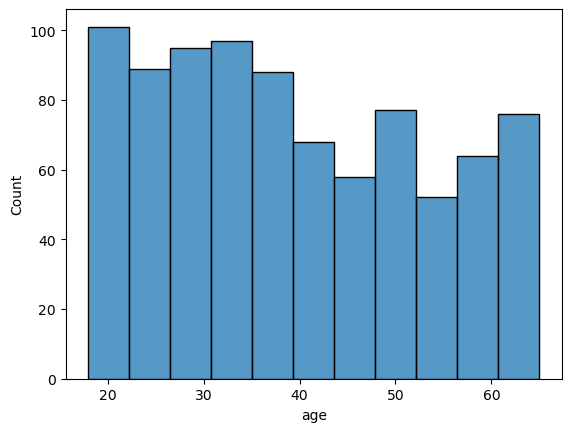

In [14]:
sns.histplot(users_info_cleaned, x = "age")
plt.show()

### 2. Распределение по городам и полу

- расчёт количества пользователей по полу и городу

- построение сводной таблицы (города × пол)

- вычисление доли женщин в каждом городе

- визуализация

- определение города-аномалии

In [15]:
# Количество пользователей по полу и городу
gender_cnt = pd.pivot_table(users_info_cleaned,\
                           index = 'city',\
                           columns = 'gender',\
                           values = 'id_user',
                           aggfunc = 'count')
gender_cnt

gender,female,male
city,,
Екатеринбург,55,78
Казань,53,77
Москва,220,105
СПб,123,154


In [16]:
# Доля женщтн по городам
female_share = users_info_cleaned\
    .groupby('city')\
    .agg(female_share = ('gender', lambda x: round((x == 'female').sum() / x.count(), 2)))\
    .reset_index()
female_share

,city,female_share
0,Екатеринбург,0.41
1,Казань,0.41
2,Москва,0.68
3,СПб,0.44


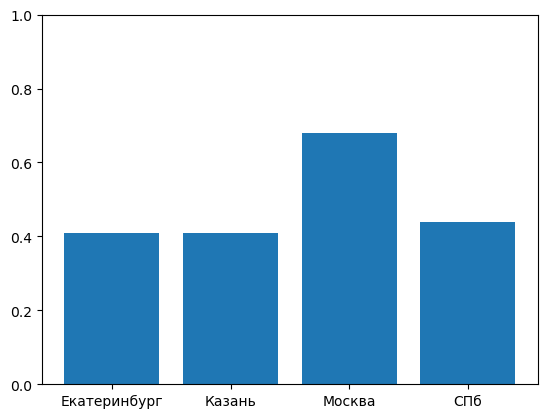

In [17]:
plt.bar(female_share['city'], female_share['female_share'])
plt.ylim(0,1)
plt.show()

Среди всех городов наибольшая доля женщин в Москве

### 3. Сегментация по активности

- расчёт среднеего кол-ва тренировок в месяц на пользователя

- бинирование пользователей на 3 группы активности

- подсчёт количества в каждой группе

In [18]:
pay_mon = pd.read_csv('../data/payments_monthly.csv')

In [19]:
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [20]:
pivot_df_avg_cnt_tr_by_users = pay_mon\
    .groupby('id_user')\
    .agg(avg_cnt_tr_per_month = ('cnt_total', lambda x: round(x.sum() / x.count(), 2)))\
    .reset_index()
pivot_df_avg_cnt_tr_by_users

,id_user,avg_cnt_tr_per_month
0,1000,3.67
1,1001,11.73
2,1002,11.64
3,1003,5.17
4,1004,2.00
...,...,...
964,1994,7.00
965,1995,11.50
966,1996,1.50
967,1997,5.00


In [21]:
bins = [0, 4, 11, float('inf')]
labels = ["мало (0-4)", "средне(5-11)", "много(12+)"]

In [22]:
pd.cut(pivot_df_avg_cnt_tr_by_users['avg_cnt_tr_per_month'], bins = bins, labels = labels, right=True).value_counts()

средне(5-11)    515
мало (0-4)      336
много(12+)      118
Name: avg_cnt_tr_per_month, dtype: int64